# Import libraries

In [25]:
import cv2
import os
from utils import fetch_data, draw_rectangle, display_rectangle, draw_text, select_roi, fetch_models

In [27]:
fetch_models()

### Step 1
Decide what video you are going to use for this homework, select an object and generate the template.
You can use any video you want (your own, from Youtube, etc.)
and track any object you want (e.g. a car, a pedestrian, etc.).

In [28]:
path_to_video = '../../video/6km_nissan_z340.mp4'
video = cv2.VideoCapture(path_to_video)
video.set(cv2.CAP_PROP_POS_FRAMES, 15) # Skip first 15 frames to avoid the intro

True

Bbox selected: (280, 196, 551, 402)


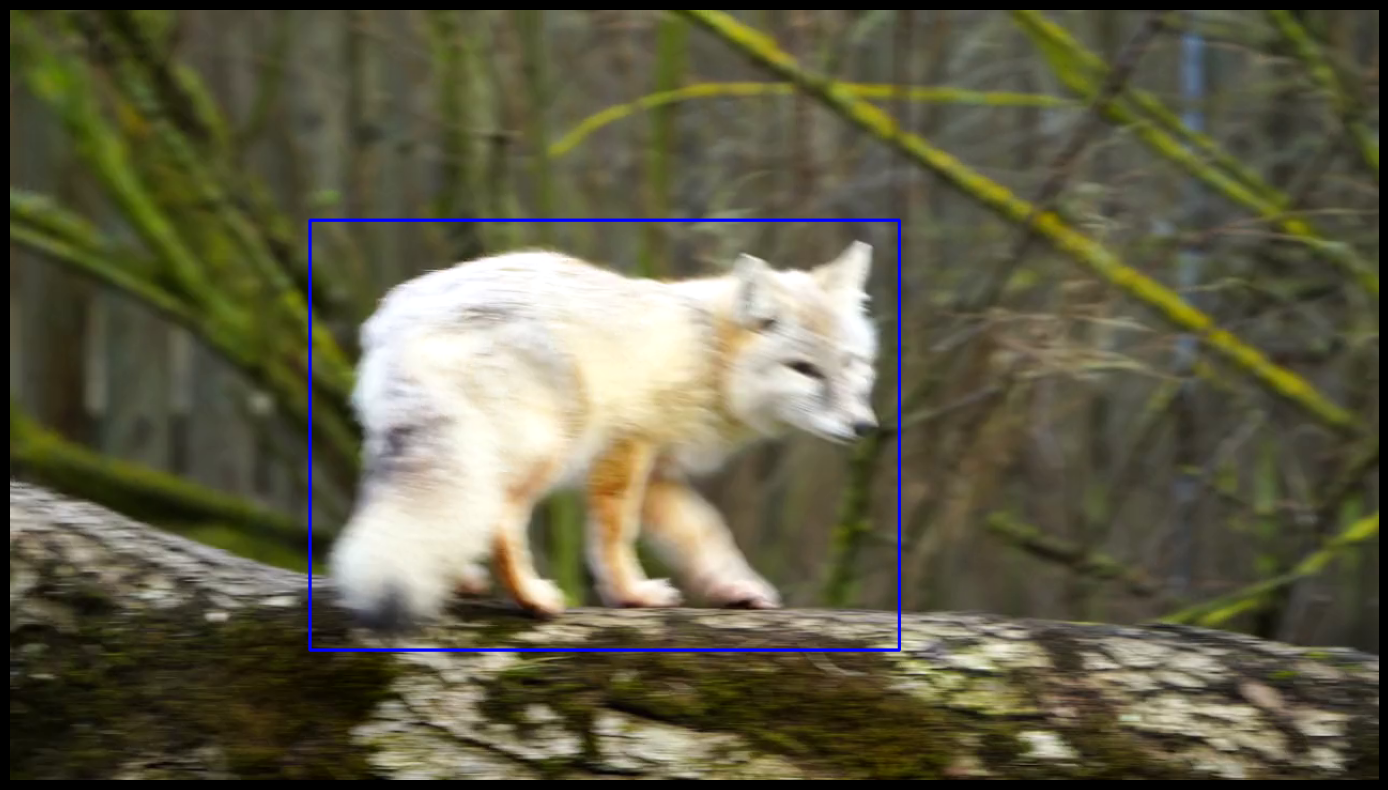

In [29]:
ok, frame = video.read()
if not ok:
    raise RuntimeError("Failed to read first frame")

# Drag a rectangle with the mouse, press ENTER/SPACE to confirm, or ESC to cancel
object_template = select_roi(frame)

# bbox is (x, y, w, h)
if object_template == (0, 0, 0, 0):
    raise RuntimeError("ROI selection canceled")


# video.release()
cv2.destroyAllWindows()

print(f'Bbox selected: {object_template}')
display_rectangle(frame, object_template)

### Step 2
Initialize a tracker (e.g. KCF).

In [30]:
backbone = '../models/nanotrack_backbone_sim.onnx'
neckhead = '../models/nanotrack_head_sim.onnx'

params = cv2.TrackerNano_Params()
params.backbone = str(backbone)
params.neckhead = str(neckhead)
params.backend = cv2.dnn.DNN_BACKEND_OPENCV
params.target = cv2.dnn.DNN_TARGET_CPU

tracker = cv2.TrackerNano.create(params)
tracker.init(frame, object_template)

### Step 3
Run the tracker on the video and the selected object. Run the tracker for around 10-15 frames.

In [31]:
frame_cnt = 0
out_dir = "nano_frames"
os.makedirs(out_dir, exist_ok=True)

while True:
    frame_cnt += 1

    # Capture the video frame by frame
    ok, frame = video.read()

    if not ok:
        break

    # Update tracker
    ok, bbox = tracker.update(frame)

    # Draw bounding box
    if ok:
        draw_rectangle(frame, bbox)
    else:
        draw_text(frame, "Tracking failure detected", (80, 140), (0, 0, 255))

    cv2.imshow('frame', frame)
    ### Step 4
    # For each frame, print the bounding box on the image and save it.
    # Save only each 25th frame
    if frame_cnt % 25 == 0:
        cv2.imwrite(os.path.join(out_dir, f"frame_{frame_cnt:06d}.jpg"), frame)


    # The 'q' button is set as the quitting button
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# After the loop release the cap object and destroy all the windows
video.release()
cv2.destroyAllWindows()

### Step 5
Select a different tracker (e.g. CSRT) and repeat steps 2, 3 and 4.

In [32]:
video = cv2.VideoCapture(path_to_video)
video.set(cv2.CAP_PROP_POS_FRAMES, 15) # Skip first 15 frames to avoid the intro

ok, frame = video.read()

# initialize params for DaSiamRPN
params = cv2.TrackerDaSiamRPN_Params()

params.model = 'models/dasiamrpn_model.onnx'
params.kernel_cls1 = 'models/dasiamrpn_kernel_cls1.onnx'
params.kernel_r1 = 'models/dasiamrpn_kernel_r1.onnx'
params.backend = cv2.dnn.DNN_BACKEND_OPENCV
params.target = cv2.dnn.DNN_TARGET_CPU

# Create and initialize the DaSiamRPN tracker
tracker = cv2.TrackerDaSiamRPN.create(params)

# bbox = (503, 363, 88, 32) # previous bbox for NanoTrack, you can also select a new one for DaSiamRPN
tracker.init(frame, object_template)

# Set up video again to the beginning
frame_cnt = 0
out_dir = "dasiamrpn_frames"
os.makedirs(out_dir, exist_ok=True)

while True:
    frame_cnt += 1

    # Capture the video frame by frame
    ok, frame = video.read()

    if not ok:
        break

    # Update tracker
    ok, bbox = tracker.update(frame)

    # Draw bounding box
    if ok:
        draw_rectangle(frame, bbox)
    else:
        draw_text(frame, "Tracking failure detected", (80, 140), (0, 0, 255))

    cv2.imshow('frame', frame)
    ### Step 4
    # For each frame, print the bounding box on the image and save it.
    # Save only each 25th frame
    if frame_cnt % 25 == 0:
        cv2.imwrite(os.path.join(out_dir, f"frame_{frame_cnt:06d}.jpg"), frame)


    # The 'q' button is set as the quitting button
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# After the loop release the cap object and destroy all the windows
video.release()
cv2.destroyAllWindows()

### Step 6
Compare the results:
* Q: Do you see any differences? If so, what are they?
* A: Sometime NanoTrack loses the target and fails to track, while DaSiamRPN can still track the target.
 * This is because DaSiamRPN is a more advanced tracker that uses a Siamese network to learn a similarity function between the template and the search region,
   * which allows it to handle more challenging tracking scenarios such as occlusion, deformation, and scale variation.
* Q: Does one tracker perform better than the other? In what way?
* A: In this case, DaSiamRPN performs better than NanoTrack in terms of tracking accuracy and robustness. NanoTrack may lose the target or produce inaccurate bounding boxes, while DaSiamRPN can maintain a more consistent and accurate tracking performance throughout the video.

| Model     | Time | Tracking Quality |
|-----------|------|------------------|
| Nano      | 9s   | *****            |
| VIT       | 8.6s | ****             |
| DaSiamRPN | 54s  | *****            |
| GOTURN    | 31s  | ****             |
| MIL       | 53s  | ***              |